# 01 — Data Fetching & Exploration

This notebook downloads price data for the asset universe, computes returns, and explores their statistical properties.

**Contents:**
1. Download prices from Yahoo Finance
2. Compute log returns
3. Descriptive statistics & annualized metrics
4. Correlation matrix
5. Distribution analysis (normality test)

In [10]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from src.data_fetcher.fetcher import download_prices, compute_returns, describe_returns
from src.utils.plotting import plot_correlation_heatmap
from config import TICKERS, START_DATE, PRICE_FREQUENCY, RETURN_TYPE

pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Download Price Data

In [11]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    interval=PRICE_FREQUENCY,
    cache_dir='../data/',
)
print(f'Shape: {prices.shape}')
prices.tail()

[Cache] Loading prices from ../data/prices_1mo_2014-01-01.csv
Shape: (150, 8)


,SPY,EZU,EEM,TLT,LQD,EMB,GLD,GSG
Date,,,,,,,,
2026-02-01,684.1216,68.5800,62.5800,89.1342,109.5860,95.6213,483.7500,25.9600
2026-03-01,648.5688,62.6400,56.7900,85.4063,107.3425,92.2999,430.2900,32.2500
2026-04-01,718.6600,66.6200,63.9900,84.6326,107.5735,94.5273,423.6600,34.3900
2026-05-01,756.4800,68.7800,68.6000,85.1097,108.5216,95.6121,417.1200,31.8000
2026-06-01,759.5700,69.3400,70.8000,85.6500,108.9200,96.2600,411.9500,32.6300


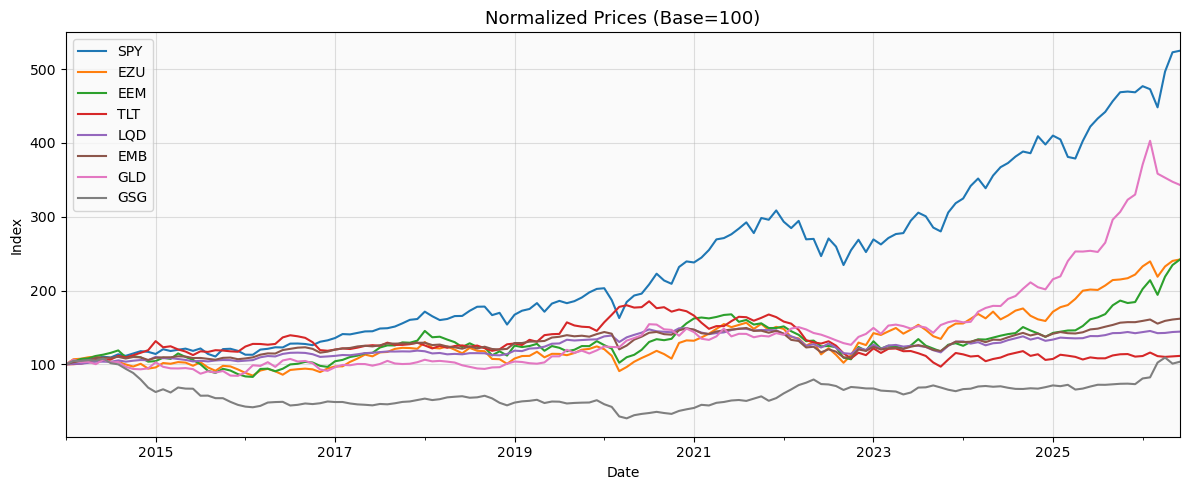

In [12]:
# Plot normalized prices (rebased to 100)
fig, ax = plt.subplots(figsize=(12, 5))
(prices / prices.iloc[0] * 100).plot(ax=ax, lw=1.5)
ax.set_title('Normalized Prices (Base=100)', fontsize=13)
ax.set_ylabel('Index')
plt.tight_layout()
plt.savefig('../results/01_prices.png', dpi=150)
plt.show()

## 2. Compute Returns

In [13]:
returns = compute_returns(prices, method=RETURN_TYPE, winsorize_sigma=3.0)
print(f'Returns shape: {returns.shape}')
returns.tail()

Returns shape: (149, 8)


,SPY,EZU,EEM,TLT,LQD,EMB,GLD,GSG
Date,,,,,,,,
2026-02-01,-0.0087,0.0284,0.0572,0.0415,0.0100,0.0118,0.0836,0.0187
2026-03-01,-0.0534,-0.0906,-0.0971,-0.0427,-0.0207,-0.0354,-0.1171,0.1961
2026-04-01,0.1026,0.0616,0.1194,-0.0091,0.0021,0.0238,-0.0155,0.0642
2026-05-01,0.0513,0.0319,0.0696,0.0056,0.0088,0.0114,-0.0156,-0.0783
2026-06-01,0.0041,0.0081,0.0316,0.0063,0.0037,0.0068,-0.0125,0.0258


## 3. Descriptive Statistics

In [14]:
stats_df = describe_returns(returns)
print('\n=== Annualized Statistics ===')
display(stats_df)


=== Annualized Statistics ===


,Ann. Return (%),Ann. Vol (%),Skewness,Excess Kurtosis,Min (%),Max (%),Obs.,Sharpe (proxy)
SPY,13.5300,14.7000,-0.4340,0.6800,-11.7600,12.5400,149,0.9200
EZU,7.4300,17.7500,-0.1790,0.5390,-15.2600,16.4500,149,0.4190
EEM,7.3500,16.9700,-0.0560,0.3990,-14.3000,14.4900,149,0.4330
TLT,0.8800,13.2300,0.1060,0.2540,-9.9200,10.4800,149,0.0670
LQD,2.9700,7.7600,-0.1580,1.3180,-6.5200,7.0200,149,0.3830
EMB,4.4700,8.7100,-0.3660,1.6920,-8.0600,8.7100,149,0.5130
GLD,9.9300,14.8700,0.1890,0.0040,-11.7100,11.5800,149,0.6680
GSG,1.4600,20.7100,-0.2510,0.9110,-19.5600,19.6100,149,0.0700


## 4. Correlation Matrix

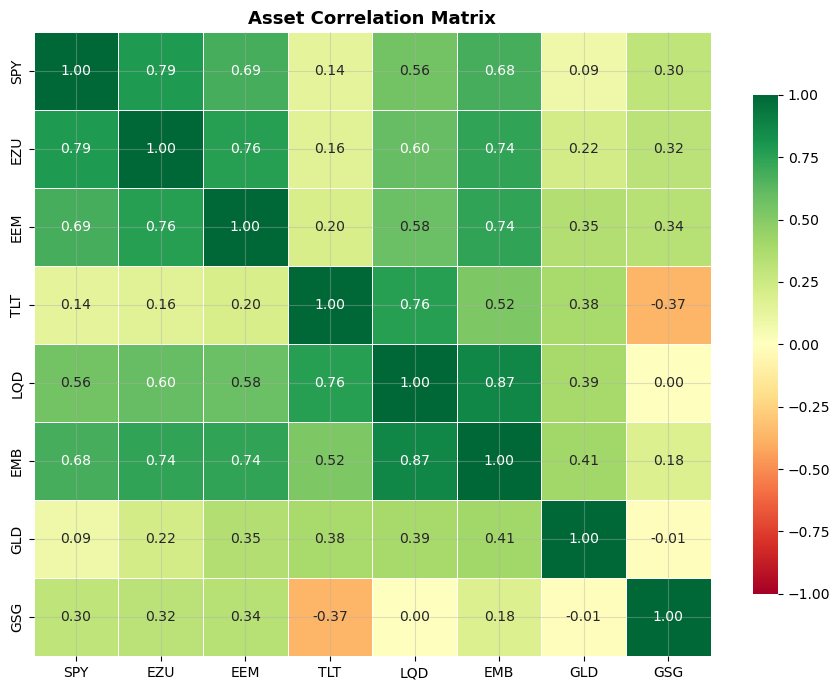

Note: Low/negative correlations between equity and bonds are the foundation of diversification.


In [15]:
fig = plot_correlation_heatmap(returns, save_path='../results/01_correlation.png')
plt.show()
print('Note: Low/negative correlations between equity and bonds are the foundation of diversification.')

## 5. Normality Test (Jarque-Bera)

Markowitz assumes normal returns. Let's check how far reality deviates.

In [16]:
print('Jarque-Bera Normality Test (p-value < 0.05 → reject normality)\n')
for col in returns.columns:
    jb_stat, p_val = stats.jarque_bera(returns[col].dropna())
    flag = '❌ Non-normal' if p_val < 0.05 else '✓ Normal'
    print(f'  {col:6s}: stat={jb_stat:7.2f}, p={p_val:.4f}  {flag}')

Jarque-Bera Normality Test (p-value < 0.05 → reject normality)

  SPY   : stat=   6.95, p=0.0310  ❌ Non-normal
  EZU   : stat=   2.22, p=0.3300  ✓ Normal
  EEM   : stat=   0.82, p=0.6640  ✓ Normal
  TLT   : stat=   0.54, p=0.7649  ✓ Normal
  LQD   : stat=  10.06, p=0.0065  ❌ Non-normal
  EMB   : stat=  19.07, p=0.0001  ❌ Non-normal
  GLD   : stat=   0.87, p=0.6461  ✓ Normal
  GSG   : stat=   5.93, p=0.0515  ✓ Normal


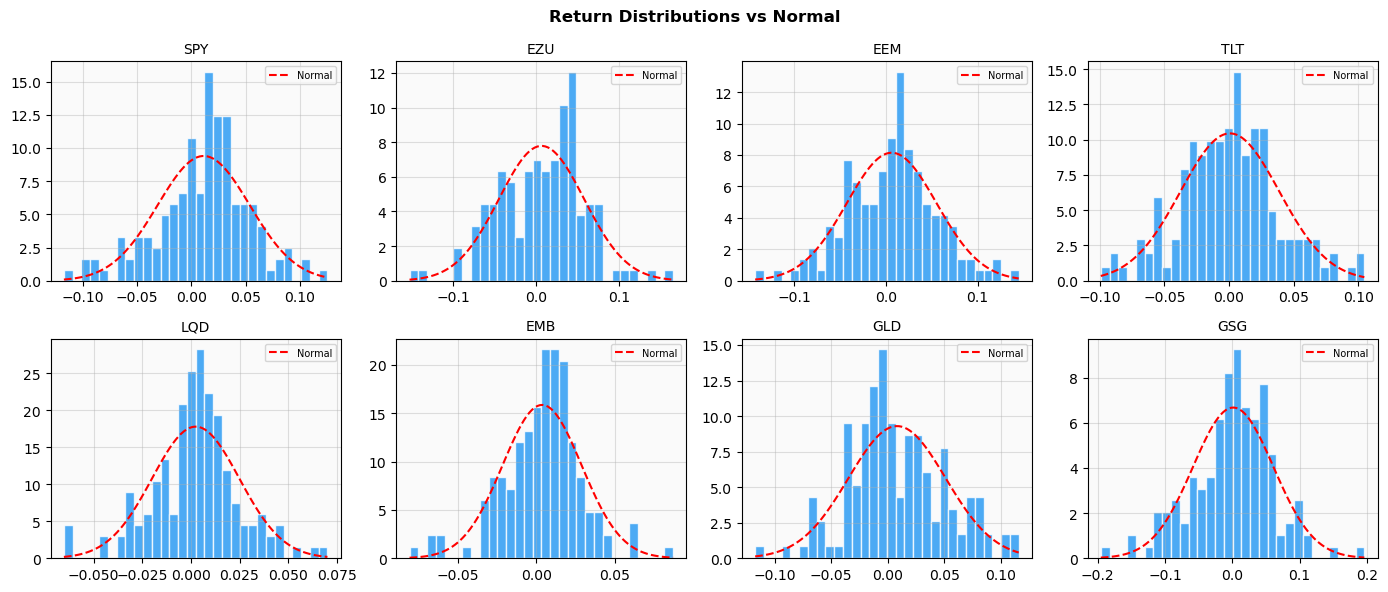


→ Fat tails justify the use of CVaR over VaR/variance as risk measure.


In [17]:
# Return distribution plots
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, (col, ax) in enumerate(zip(returns.columns, axes.flat)):
    ax.hist(returns[col], bins=30, color='#2196F3', edgecolor='white', alpha=0.8, density=True)
    x = np.linspace(returns[col].min(), returns[col].max(), 100)
    ax.plot(x, stats.norm.pdf(x, returns[col].mean(), returns[col].std()), 'r--', lw=1.5, label='Normal')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Return Distributions vs Normal', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/01_distributions.png', dpi=150)
plt.show()

print('\n→ Fat tails justify the use of CVaR over VaR/variance as risk measure.')

In [18]:
returns.to_csv('../data/returns.csv')
print('Returns saved to ../data/returns.csv ✓')

Returns saved to ../data/returns.csv ✓
